In [1]:
import os
import pandas as pd 
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent   # notebooks/ -> project root
sys.path.append(str(PROJECT_ROOT))

data_paths_dict = { 
    "identity": os.path.join(PROJECT_ROOT, "data/raw/identity.csv"), 
    "transaction": os.path.join(PROJECT_ROOT, "data/raw/transaction.csv")
}

In [2]:
from src.preprocessing.clean import CleanData

In [ ]:
features_dict, auc_dict = {}, {}
missing_threshold_list = [0.9, 0.95]
fi_threshold_list = [0.8, 0.85, 0.9, 0.95]

for missing_threshold in missing_threshold_list: 
    features_dict[missing_threshold], auc_dict[missing_threshold] = {}, {}
    for fi_threshold in fi_threshold_list: 
        pipeline = CleanData(
            data_paths_dict,
            missing_threshold,
            fi_threshold
        )
        df = pipeline.merge_data()
        df = pipeline.drop_dead_columns(df)
        _, df = pipeline.missingness_pvalues(df)
        df, _ = pipeline.get_feature_importance(df)
        auc = pipeline.get_test_auc(df)
        features_dict[missing_threshold][fi_threshold] = df.shape[1]
        auc_dict[missing_threshold][fi_threshold] = auc

There are 34 features of zero importance
Keeping 60 features at 80.0% cumulative importance
There are 34 features of zero importance
Keeping 79 features at 85.0% cumulative importance
There are 34 features of zero importance
Keeping 103 features at 90.0% cumulative importance
There are 34 features of zero importance
Keeping 137 features at 95.0% cumulative importance
There are 29 features of zero importance
Keeping 58 features at 80.0% cumulative importance
There are 29 features of zero importance
Keeping 77 features at 85.0% cumulative importance
There are 29 features of zero importance
Keeping 101 features at 90.0% cumulative importance
There are 29 features of zero importance
Keeping 137 features at 95.0% cumulative importance


In [28]:
features_df = (
    pd.DataFrame.from_dict(features_dict, orient="index")
      .stack()
      .reset_index()
)

features_df.columns = ["missing_threshold", "fi_threshold", "features"]

auc_df = (
    pd.DataFrame.from_dict(auc_dict, orient="index")
      .stack()
      .reset_index()
)

auc_df.columns = ["missing_threshold", "fi_threshold", "auc"]

auc_feature_df = features_df.merge(
    right=auc_df, 
    how = "inner", 
    on = ["missing_threshold", "fi_threshold"]
)

auc_feature_df

,missing_threshold,fi_threshold,features,auc
0,0.90,0.80,61,0.882736
1,0.90,0.85,80,0.889971
2,0.90,0.90,104,0.890983
3,0.90,0.95,138,0.894055
4,0.95,0.80,59,0.869308
5,0.95,0.85,78,0.883045
6,0.95,0.90,102,0.891184
7,0.95,0.95,138,0.894360


The configuration with a missing-value threshold of 0.95 and a cumulative feature-importance threshold of 0.90 was selected because it achieved an AUC of 0.8912 using 102 features. Increasing the feature-importance threshold to 0.95 improved AUC by only 0.0032 while requiring 36 additional features, indicating that the 0.95/0.90 configuration provided the best trade-off between predictive performance and model complexity.

In [3]:
pipeline = CleanData(
	data_paths_dict,
	0.95,
	0.90
)
df = pipeline.merge_data()
df = pipeline.drop_dead_columns(df)
_, df = pipeline.missingness_pvalues(df)
df, importance = pipeline.get_feature_importance(df)

There are 29 features of zero importance
Keeping 101 features at 90.0% cumulative importance


In [4]:
float_cols = df.select_dtypes(include="float64").columns
object_cols = df.select_dtypes(include="object").columns
# Don't want to include int (variable is isFraud which is the target variable)

In [5]:
numerical_cols = [] 
categorical = (
        ['ProductCD']
        + [f'card{i}' for i in range(1, 7)]        # card1 - card6
        + ['addr1', 'addr2']
        + ['P_emaildomain', 'R_emaildomain']
        + [f'M{i}' for i in range(1, 10)]           # M1 - M9
        + ['DeviceType', 'DeviceInfo']
        + [f'id_{i}' for i in range(12, 39)]        # id_12 - id_38
    )

exclude = set(categorical)
numerical = [col for col in df.columns if col not in exclude]

print(len(numerical))

87


In [6]:
pipeline.get_redundant_pairs(df, numerical, 0.85)

,col_a,col_b,value_corr,missingness_match
0,V179,V213,0.996031,1.000000
1,V168,V213,0.995785,1.000000
2,V179,V168,0.995005,1.000000
3,V233,V232,0.994496,1.000000
4,V219,V232,0.990591,1.000000
...,...,...,...,...
80,V30,V11,0.856554,0.655326
81,V261,V262,0.854025,1.000000
82,V70,V10,0.853592,0.657590
83,V248,V243,0.852932,1.000000


In [11]:
numerical

['V258',
 'V225',
 'V189',
 'V207',
 'V91',
 'V219',
 'V70',
 'V198',
 'V22',
 'V54',
 'V72',
 'V179',
 'V257',
 'id_04',
 'V188',
 'V248',
 'D3',
 'V94',
 'V271',
 'V243',
 'V200',
 'V29',
 'V256',
 'V227',
 'V199',
 'V87',
 'V233',
 'V261',
 'V168',
 'V76',
 'V62',
 'V180',
 'V232',
 'V67',
 'V74',
 'V205',
 'V209',
 'V204',
 'V249',
 'id_03',
 'D2',
 'V58',
 'V217',
 'V251',
 'V169',
 'V82',
 'V75',
 'V56',
 'V30',
 'V33',
 'V13',
 'D7',
 'V23',
 'V216',
 'V83',
 'id_09',
 'V218',
 'V181',
 'V212',
 'V26',
 'V3',
 'V220',
 'V192',
 'V187',
 'D8',
 'V5',
 'V226',
 'V20',
 'D15',
 'id_06',
 'dist1',
 'V170',
 'D12',
 'V59',
 'D11',
 'V61',
 'V11',
 'D10',
 'V182',
 'V10',
 'V201',
 'V262',
 'id_11',
 'V53',
 'D13',
 'V213',
 'isFraud']

In [12]:
df, columns = pipeline.drop_redundant(df, importance, numerical, 0.85)

In [13]:
df.columns

Index(['V258', 'V225', 'V189', 'V207', 'V91', 'V219', 'V198', 'V22', 'V54',
       'V72', 'V257', 'id_04', 'V248', 'D3', 'V271', 'M2', 'V200', 'V256',
       'V227', 'DeviceInfo', 'V87', 'V261', 'V76', 'R_emaildomain', 'V62',
       'V180', 'V67', 'M4', 'V205', 'M3', 'V209', 'id_03', 'D2', 'V251',
       'V169', 'V82', 'V56', 'V13', 'D7', 'id_38', 'V23', 'V216', 'id_17',
       'id_09', 'V181', 'M6', 'V26', 'V3', 'addr1', 'V220', 'V192', 'D8',
       'id_31', 'id_12', 'V5', 'id_20', 'V226', 'V20', 'M9', 'D15', 'id_06',
       'dist1', 'V170', 'D12', 'addr2', 'D11', 'id_15', 'D10', 'id_11', 'D13',
       'isFraud'],
      dtype='object')

<Axes: xlabel='V258', ylabel='count'>

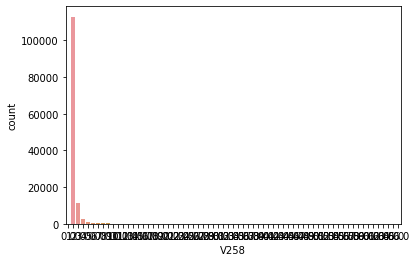

In [21]:
import seaborn as sns

sns.countplot(data=df, x="V258")

In [22]:
df

,V258,V225,V189,V207,V91,V219,V198,V22,V54,V72,...,dist1,V170,D12,addr2,D11,id_15,D10,id_11,D13,isFraud
0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,1.0,0.0,...,19.0,NaN,NaN,87.0,13.0,NaN,13.0,NaN,NaN,0
1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,87.0,NaN,NaN,0.0,NaN,NaN,0
2,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,1.0,0.0,...,287.0,NaN,NaN,87.0,315.0,NaN,0.0,NaN,NaN,0
3,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,1.0,0.0,...,NaN,NaN,NaN,87.0,NaN,NaN,84.0,NaN,NaN,0
4,1.0,0.0,1.0,0.0,NaN,0.0,1.0,NaN,NaN,NaN,...,NaN,1.0,NaN,87.0,NaN,New,NaN,100.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,0.0,...,48.0,NaN,NaN,87.0,56.0,NaN,56.0,NaN,NaN,0
590536,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,1.0,0.0,...,NaN,NaN,NaN,87.0,0.0,NaN,0.0,NaN,NaN,0
590537,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0,0.0,...,NaN,NaN,NaN,87.0,0.0,NaN,0.0,NaN,NaN,0
590538,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,1.0,0.0,...,3.0,NaN,NaN,87.0,22.0,NaN,22.0,NaN,NaN,0


In [19]:
df["V258"].value_counts()

V258
1.0     112953
2.0      11247
3.0       2696
4.0       1062
5.0        569
         ...  
50.0         1
41.0         1
42.0         1
43.0         1
52.0         1
Name: count, Length: 67, dtype: int64

In [15]:
df.isnull().sum().sort_values()

isFraud         0
addr2       65706
addr1       65706
D10         76022
V20         76073
            ...  
id_04      524216
id_03      524216
D12        525823
D13        528588
D7         551623
Length: 71, dtype: int64

In [17]:
df["dist1"]

0          19.0
1           NaN
2         287.0
3           NaN
4           NaN
          ...  
590535     48.0
590536      NaN
590537      NaN
590538      3.0
590539      NaN
Name: dist1, Length: 590540, dtype: float64

In [14]:
object_cols

Index(['M2', 'DeviceInfo', 'R_emaildomain', 'M4', 'M3', 'id_38', 'M6', 'id_31',
       'id_12', 'M9', 'id_15'],
      dtype='object')

In [13]:
df_columns

NameError: name 'df_columns' is not defined

In [32]:
df.isnull().sum().sort_values(ascending=True)

isFraud         0
addr2       65706
addr1       65706
D10         76022
V29         76073
            ...  
id_03      524216
id_04      524216
D12        525823
D13        528588
D7         551623
Length: 102, dtype: int64

In [43]:
df["D7"].value_counts()

D7
0.0      21135
1.0       1717
2.0        998
3.0        791
7.0        606
         ...  
708.0        1
628.0        1
724.0        1
491.0        1
578.0        1
Name: count, Length: 597, dtype: int64

In [47]:
df["D7"].describe()

count    38917.000000
mean        41.638950
std         99.743264
min          0.000000
25%          0.000000
50%          0.000000
75%         17.000000
max        843.000000
Name: D7, dtype: float64

In [55]:
V_list = [col for col in df.columns if col.startswith("V")]
print(len(V_list))

71


In [59]:
corr_matrix = df[V_list].corr()[:30]
corr_matrix

,V258,V225,V189,V207,V91,V219,V70,V198,V22,V54,...,V170,V59,V61,V11,V182,V10,V201,V262,V53,V213
V258,1.000000,0.636657,0.461633,0.015748,NaN,0.232524,NaN,0.135077,-0.018894,NaN,...,0.503286,0.025079,0.046850,NaN,0.093247,NaN,0.637254,0.602793,NaN,0.099673
V225,0.636657,1.000000,-0.001513,0.139188,NaN,0.384007,NaN,-0.030529,-0.000085,NaN,...,0.073132,0.056515,-0.130929,NaN,0.369040,NaN,0.008020,0.614214,NaN,0.328435
V189,0.461633,-0.001513,1.000000,-0.067249,NaN,0.070851,NaN,0.596779,-0.033683,NaN,...,0.604551,0.008727,0.073069,NaN,-0.004864,NaN,0.801707,0.096798,NaN,-0.003061
V207,0.015748,0.139188,-0.067249,1.000000,NaN,0.132218,NaN,-0.096330,-0.017425,NaN,...,-0.037816,-0.025033,-0.104303,NaN,0.332643,NaN,-0.040692,0.045321,NaN,0.172013
V91,NaN,NaN,NaN,NaN,1.000000,NaN,0.907717,NaN,-0.271043,0.056259,...,NaN,-0.263158,-0.102708,0.884841,NaN,0.871561,NaN,NaN,0.062300,NaN
V219,0.232524,0.384007,0.070851,0.132218,NaN,1.000000,NaN,0.023600,-0.005404,NaN,...,0.116119,0.012109,-0.185871,NaN,0.804173,NaN,0.095591,0.324345,NaN,0.914941
V70,NaN,NaN,NaN,NaN,0.907717,NaN,1.000000,NaN,-0.261790,0.094140,...,NaN,-0.260743,-0.048534,0.861591,NaN,0.853592,NaN,NaN,0.094008,NaN
V198,0.135077,-0.030529,0.596779,-0.096330,NaN,0.023600,NaN,1.000000,-0.089437,NaN,...,0.230691,0.023280,0.072776,NaN,0.007414,NaN,0.385889,0.018854,NaN,-0.002398
V22,-0.018894,-0.000085,-0.033683,-0.017425,-0.271043,-0.005404,-0.261790,-0.089437,1.000000,-0.414303,...,-0.016266,0.872530,0.100160,NaN,-0.007671,NaN,-0.016593,0.013121,-0.403230,-0.005538
V54,NaN,NaN,NaN,NaN,0.056259,NaN,0.094140,NaN,-0.414303,1.000000,...,NaN,-0.411014,0.046164,-0.123094,NaN,-0.130286,NaN,NaN,0.920436,NaN


c:\Users\Gordon Li\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='D7', ylabel='Count'>

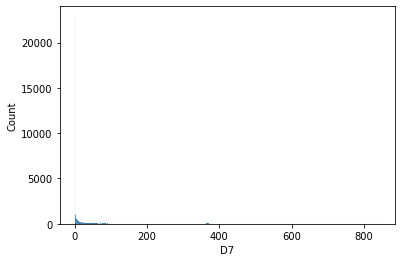

In [44]:
import seaborn as sns

sns.histplot(data=df, x="D7")

In [38]:
df["addr1"]

0         315.0
1         325.0
2         330.0
3         476.0
4         420.0
          ...  
590535    272.0
590536    204.0
590537    231.0
590538    387.0
590539    299.0
Name: addr1, Length: 590540, dtype: float64

In [39]:
df["addr2"]

0         87.0
1         87.0
2         87.0
3         87.0
4         87.0
          ... 
590535    87.0
590536    87.0
590537    87.0
590538    87.0
590539    87.0
Name: addr2, Length: 590540, dtype: float64

In [40]:
df['addr1'].corr(df['addr2'])

-0.0027650436718925854

In [41]:
df[['addr1', 'addr2']].nunique()

addr1    332
addr2     74
dtype: int64

In [42]:
(df['addr1'].isna() == df['addr2'].isna()).mean()

1.0

In [24]:
statement = "Hi Henry, noticed the Investment Risk quant role at Cbus. UNSW Stats Honours (First Class) grad here, built a systematic ASX equities strategy — dashboard.systematic-equities-alpha.com. What's the team's biggest focus, risk modelling or research? Gordon"

In [25]:
print(len(statement))

253


In [3]:
print(os.listdir(PROJECT_ROOT))

['.git', '.gitignore', '.vscode', 'data', 'notebooks', 'src']


In [5]:
import os, sys
print("On sys.path?", PROJECT_ROOT in sys.path)
print("src/__init__.py exists?", os.path.exists(os.path.join(PROJECT_ROOT, "src", "__init__.py")))
print("src/preprocessing/__init__.py exists?", os.path.exists(os.path.join(PROJECT_ROOT, "src", "preprocessing", "__init__.py")))
print(os.listdir(os.path.join(PROJECT_ROOT, "src")))

On sys.path? True
src/__init__.py exists? True
src/preprocessing/__init__.py exists? True
['data', 'pipeline.py', 'preprocessing', '__init__.py']


In [5]:
from src.preprocessing.clean import CleanData

ModuleNotFoundError: No module named 'src'